In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os 
import numpy as np


In [6]:
class GaussianNoiseGenerator(ImageDataGenerator):
    """
    This class is a subclass of the ImageDataGenerator class from Keras. It adds gaussian noise to the images during
    training. This is done by overriding the random_transform function of the ImageDataGenerator class.

    Attributes
    ----------
    gaussian_noise_std : float
        Standard deviation of the gaussian noise to be added to the images.

    Methods
    -------
    random_transform(x, seed=None)
        This function is the same as the original random_transform function, except for the added gaussian noise.
    """
    
    def __init__(self, gaussian_noise_std=0.1, **kwargs):
        super().__init__(**kwargs)
        self.gaussian_noise_std = gaussian_noise_std

    def random_transform(self, x, seed=None):
        """
        This function is the same as the original random_transform function, except for the added gaussian noise.

        Parameters
        ----------
        x : array-like
            Image to be transformed.
        seed : int
            Random seed.

        Returns
        -------
        A randomly transformed version of the input image.
        """
        x = super().random_transform(x, seed)
        if self.gaussian_noise_std:
            gaussian_noise = np.random.normal(loc=0.0, scale=self.gaussian_noise_std, size=x.shape)
            x = x + gaussian_noise
            x = np.clip(x, 0, 1)
        return x


In [7]:
# Define the data generators for training and validation
train_datagen = GaussianNoiseGenerator(
    rescale=1./255,
    horizontal_flip=True,
    gaussian_noise_std=0.1  # Standard deviation for the Gaussian noise
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
train_generator = train_datagen.flow_from_directory(
    os.path.join("FER13", "train"),
    target_size=(48, 48),
    batch_size=64,
    class_mode='categorical',
    color_mode="grayscale",
    # shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    os.path.join("FER13", "test"),
    target_size=(48, 48),
    batch_size=64,
    class_mode='categorical',
    color_mode="grayscale",
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [81]:
# Load the ResNet50 model pre-trained on ImageNet data
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(48, 48, 3))

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

In [82]:
# Check GPU availability
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

GPU is available


In [83]:
model = models.Sequential([
    base_model,
    layers.GlobalMaxPooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')  # 7 classes for the FER2013 dataset
])

model.summary()

Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2, 2, 2048)        23587712  
                                                                 
 global_max_pooling2d_6 (Gl  (None, 2048)              0         
 obalMaxPooling2D)                                               
                                                                 
 dense_34 (Dense)            (None, 512)               1049088   
                                                                 
 dropout_33 (Dropout)        (None, 512)               0         
                                                                 
 dense_35 (Dense)            (None, 7)                 3591      
                                                                 
Total params: 24640391 (94.00 MB)
Trainable params: 1052679 (4.02 MB)
Non-trainable params: 23587712 (89.98 MB)
_______

In [84]:
model2 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),
    
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),
    
    layers.Conv2D(256, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),
    
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(7, activation='softmax')
])

model2.summary()

Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_20 (Conv2D)          (None, 46, 46, 32)        320       
                                                                 
 conv2d_21 (Conv2D)          (None, 44, 44, 64)        18496     
                                                                 
 max_pooling2d_15 (MaxPooli  (None, 22, 22, 64)        0         
 ng2D)                                                           
                                                                 
 dropout_34 (Dropout)        (None, 22, 22, 64)        0         
                                                                 
 conv2d_22 (Conv2D)          (None, 20, 20, 128)       73856     
                                                                 
 max_pooling2d_16 (MaxPooli  (None, 10, 10, 128)       0         
 ng2D)                                               

In [85]:
# Compile the model
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [87]:
try:
    # Train the model
    history = model2.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        validation_data=val_generator,
        validation_steps=val_generator.samples // val_generator.batch_size,
        epochs=100
    )
except KeyboardInterrupt:
    print("Training interrupted by user.")



Epoch 1/100
448/448 [==============================] - 6s 12ms/step - loss: 0.8443 - accuracy: 0.6854 - val_loss: 0.9597 - val_accuracy: 0.6459
Epoch 2/100
448/448 [==============================] - 6s 12ms/step - loss: 0.8381 - accuracy: 0.6873 - val_loss: 0.9642 - val_accuracy: 0.6472
Epoch 3/100
448/448 [==============================] - 6s 12ms/step - loss: 0.8297 - accuracy: 0.6918 - val_loss: 0.9607 - val_accuracy: 0.6483
Epoch 4/100
448/448 [==============================] - 6s 12ms/step - loss: 0.8265 - accuracy: 0.6912 - val_loss: 0.9520 - val_accuracy: 0.6487
Epoch 5/100
448/448 [==============================] - 6s 12ms/step - loss: 0.8156 - accuracy: 0.6943 - val_loss: 0.9514 - val_accuracy: 0.6503
Epoch 6/100
448/448 [==============================] - 6s 12ms/step - loss: 0.8090 - accuracy: 0.6985 - val_loss: 0.9573 - val_accuracy: 0.6515
Epoch 7/100
448/448 [==============================] - 6s 12ms/step - loss: 0.8048 - accuracy: 0.6968 - val_loss: 0.9548 - val_accuracy:

In [91]:
# Evaluate the model
score = model2.evaluate(val_generator, verbose=0)

In [89]:
# save model
model2.save('models/custom.h5')

In [9]:
# Load the model
model = tf.keras.models.load_model('models/custom.h5')

In [10]:
score = model.evaluate(val_generator, verbose=0)

# Print test accuracy
print('\n', 'Test accuracy:', score[1])

# Print test loss
print('\n', 'Test loss:', score[0])

(48, 48, 1)
1/1 [==============================] - 0s 46ms/step
(1, 48, 48, 1)
TYPE:  <class 'numpy.ndarray'>
[[2.8458155e-07 6.7547706e-10 2.8330144e-06 9.6593583e-01 3.3771683e-02
  6.5113352e-07 2.8869655e-04]]
 Emotion: happy 


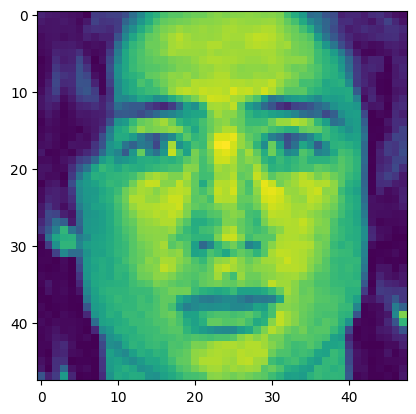

In [116]:
# Predict Image Emotion with the model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise' ]

# Load the image
img = image.load_img("FER13/test/happy/PrivateTest_10077120.jpg", target_size=(48, 48), color_mode="grayscale")

# Convert the image to array
x = image.img_to_array(img)

# Reshape the image
x = np.expand_dims(x, axis=0)

# Normalize the image
x /= 255

# Predict the emotion
model_test = tf.keras.models.load_model('models/custom.h5')
custom = model_test.predict(x)

# Print the emotion
print(f" Emotion: {classes[np.argmax(custom)]} ")

# Plot the image
img = mpimg.imread("FER13/test/neutral/PrivateTest_16736805.jpg")
plt.imshow(img)
plt.show()

In [115]:
import cv2
img = cv2.imread("FER13/test/neutral/PrivateTest_16736805.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = cv2.resize(img, (48, 48))
img = np.array(img)
img = np.expand_dims(img, axis=0)
img = np.expand_dims(img, axis=-1)
img = img/255

custom = model.predict(img)
print(f" Emotion: {classes[np.argmax(custom)]} ")


(1, 48, 48, 1)
1/1 [==============================] - 0s 12ms/step
[[0.03081354 0.00226571 0.03018364 0.04824252 0.7815658  0.10593282
  0.000996  ]]
 Emotion: neutral 
